Building intuition for a simple but important idea: All other things being equal, the more rows of data the better for ML.

Start by showing this in the case of estimating a mean from noisy measurements, where the math is simple and well-known.

n = 10
Measurements: ['55.0', '48.6', '56.5', '65.2', '47.7', '47.7', '65.8', '57.7', '45.3', '55.4']
Mean: 54.5
Standard Error of the Mean: 2.286

n = 1000
Measurements (first 20 shown): ['45.4', '45.3', '52.4', '30.9', '32.8', '44.4', '39.9', '53.1', '40.9', '35.9', '64.7', '47.7', '50.7', '35.8', '44.6', '51.1', '38.5', '53.8', '44.0', '47.1']
Mean: 50.2
Standard Error of the Mean: 0.310

Recorded results:
n=      10 | mean=53.803 | SE= 3.18039
n=      14 | mean=52.214 | SE= 2.62571
n=      22 | mean=51.765 | SE= 2.10390
n=      32 | mean=50.046 | SE= 1.86274
n=      48 | mean=52.563 | SE= 1.42719
n=      72 | mean=49.681 | SE= 1.26094
n=     108 | mean=50.697 | SE= 0.96026
n=     161 | mean=50.767 | SE= 0.77629
n=     239 | mean=50.769 | SE= 0.66104
n=     356 | mean=49.990 | SE= 0.51946
n=     529 | mean=50.070 | SE= 0.42709
n=     788 | mean=49.976 | SE= 0.35936
n=   1,172 | mean=49.534 | SE= 0.29265
n=   1,743 | mean=49.758 | SE= 0.23998
n=   2,592 | mean=49.980 | SE= 0.20389
n=

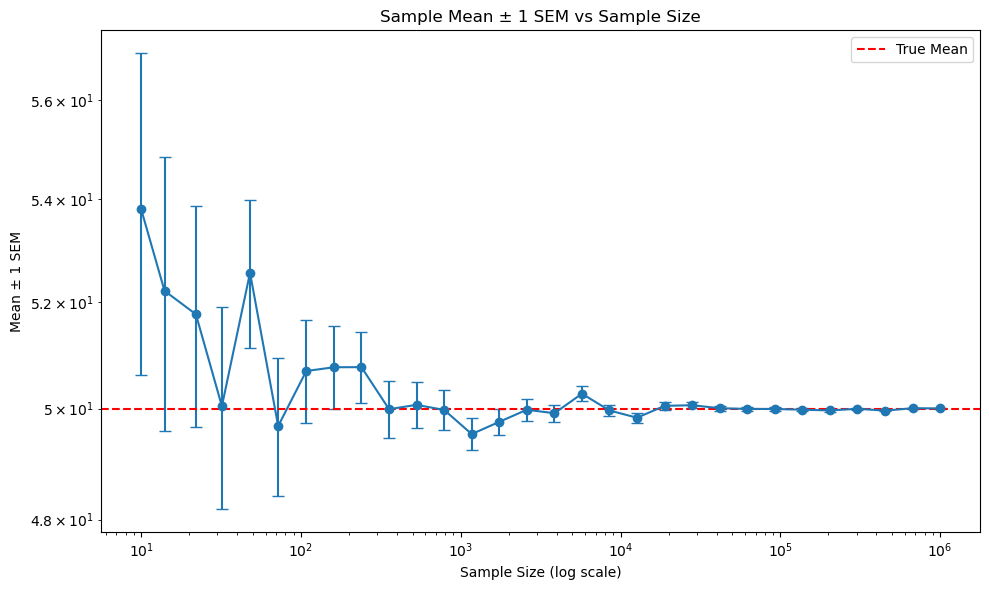

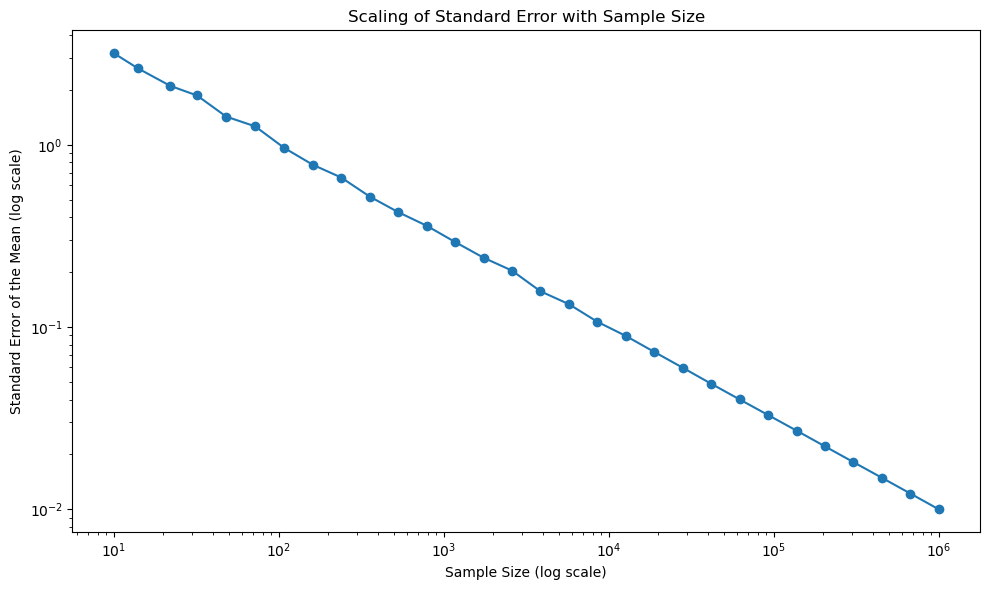

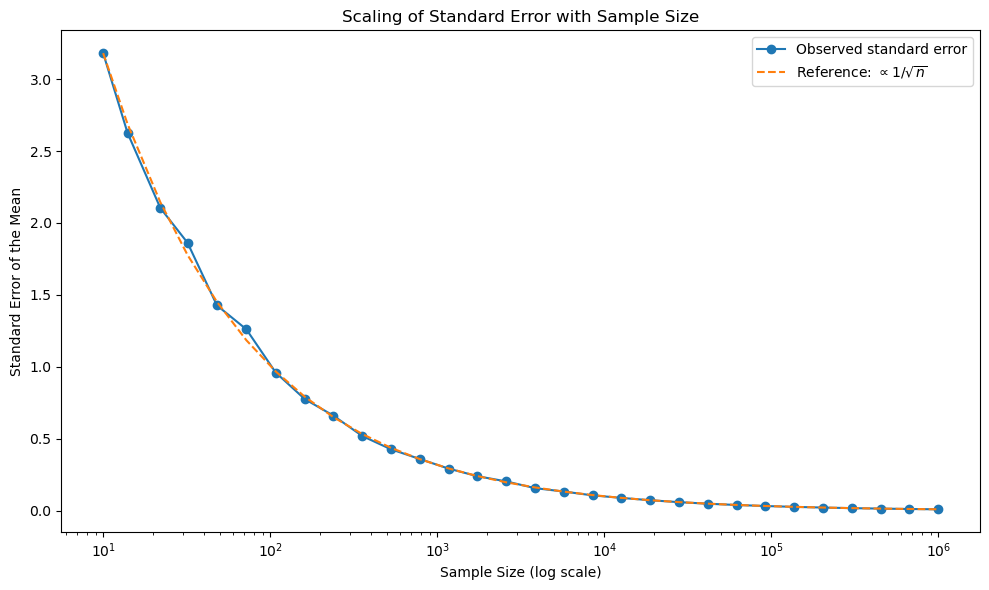

In [19]:
# Building intuition for a simple but important idea:
# All other things being equal, the more rows of data the better for ML.

# Start by showing this in the case of estimating a mean from noisy measurements, where the math is simple and well-known.

import numpy as np

np.random.seed(42)

true_mean = 50
true_std = 10

# Small example
measurements = np.random.normal(loc=true_mean, scale=true_std, size=10)
print("n = 10")
print("Measurements:", [f"{x:.1f}" for x in measurements])
print("Mean:", f"{measurements.mean():.1f}")
print("Standard Error of the Mean:", f"{(measurements.std(ddof=1) / np.sqrt(len(measurements))):.3f}")
print()

# Larger example
measurements = np.random.normal(loc=true_mean, scale=true_std, size=1000)
print("n = 1000")
print("Measurements (first 20 shown):", [f"{x:.1f}" for x in measurements[:20]])
print("Mean:", f"{measurements.mean():.1f}")
print("Standard Error of the Mean:", f"{(measurements.std(ddof=1) / np.sqrt(len(measurements))):.3f}")
print()

# -------------------------------------------------------------------
# Generate a range of sample sizes from 10 to 1,000,000
# and record the mean and standard error for later plotting
# -------------------------------------------------------------------

# Log-spaced sample sizes: 10, 18, 34, ..., 1,000,000
sizes = np.unique(np.logspace(1, 6, num=30, dtype=int))

means = []
standard_errors = []

for n in sizes:
    measurements = np.random.normal(loc=true_mean, scale=true_std, size=n)
    
    mean = measurements.mean()
    se = measurements.std(ddof=1) / np.sqrt(n)
    
    means.append(mean)
    standard_errors.append(se)

# Convert to NumPy arrays for easier plotting later
means = np.array(means)
standard_errors = np.array(standard_errors)

# Preview results
print("Recorded results:")
for n, mean, se in zip(sizes, means, standard_errors):
    print(f"n={n:>8,} | mean={mean:6.3f} | SE={se:8.5f}")

# These are now ready for plotting:
# sizes, means, standard_errors

import matplotlib.pyplot as plt

# Plot: Mean ± 1 Standard Error of the Mean (SEM)
plt.figure(figsize=(10, 6))

plt.errorbar(
    sizes,
    means,
    yerr=standard_errors,   # 1 SEM
    fmt='o-',
    capsize=4
)
# Horizontal line for true mean
plt.axhline(true_mean, color='red', linestyle='--', label='True Mean')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Mean ± 1 SEM')
plt.title('Sample Mean ± 1 SEM vs Sample Size')


plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

# Separate plot: Standard error vs sample size
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    standard_errors,
    marker='o'
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Standard Error of the Mean (log scale)')
plt.title('Scaling of Standard Error with Sample Size')

plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# Separate plot: Standard error vs sample size, with 1/sqrt(n) reference line
plt.figure(figsize=(10, 6))

# Actual observed standard errors
plt.plot(
    sizes,
    standard_errors,
    marker='o',
    label='Observed standard error'
)

# Reference scaling law: proportional to 1/sqrt(n)
# Match the reference line to the first observed point for easy visual comparison
reference_line = standard_errors[0] * np.sqrt(sizes[0] / sizes)

plt.plot(
    sizes,
    reference_line,
    linestyle='--',
    label=r'Reference: $\propto 1/\sqrt{n}$'
)

plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Standard Error of the Mean')
plt.title('Scaling of Standard Error with Sample Size')
plt.legend()

plt.tight_layout()
plt.show()

Now let's illustrate that idea for simple linear regression.

Important interpretation note:
This demonstration only cleanly shows 'more rows is better' because
the other things are being held fixed: the same true relationship,
the same noise level, and the same spread of x-values across sample sizes.

n = 10
First 10 x values: ['37.5', '95.1', '73.2', '59.9', '15.6', '15.6', '5.8', '86.6', '60.1', '70.8']
First 10 y values: ['75.2', '200.6', '146.8', '120.1', '38.6', '17.1', '-0.6', '172.6', '115.1', '149.8']
Estimated intercept: -8.364
Estimated slope: 2.151
Standard error of slope: 0.07459

n = 1000
First 10 x values: ['29.2', '36.6', '45.6', '78.5', '20.0', '51.4', '59.2', '4.6', '60.8', '17.1']
First 10 y values: ['63.0', '85.1', '96.5', '162.3', '54.3', '102.7', '124.4', '9.7', '122.2', '36.0']
Estimated intercept: 5.977
Estimated slope: 1.999
Standard error of slope: 0.01072

Recorded results:
n=      10 | intercept=   0.483 | slope= 2.07023 | SE(slope)=  0.140668
n=      14 | intercept=   4.821 | slope= 1.97946 | SE(slope)=  0.077524
n=  

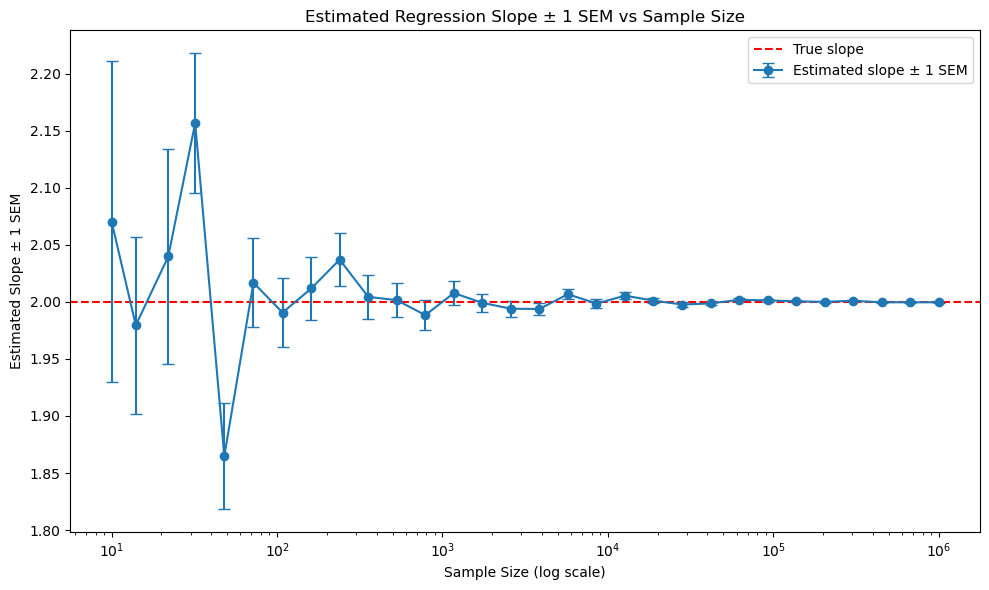

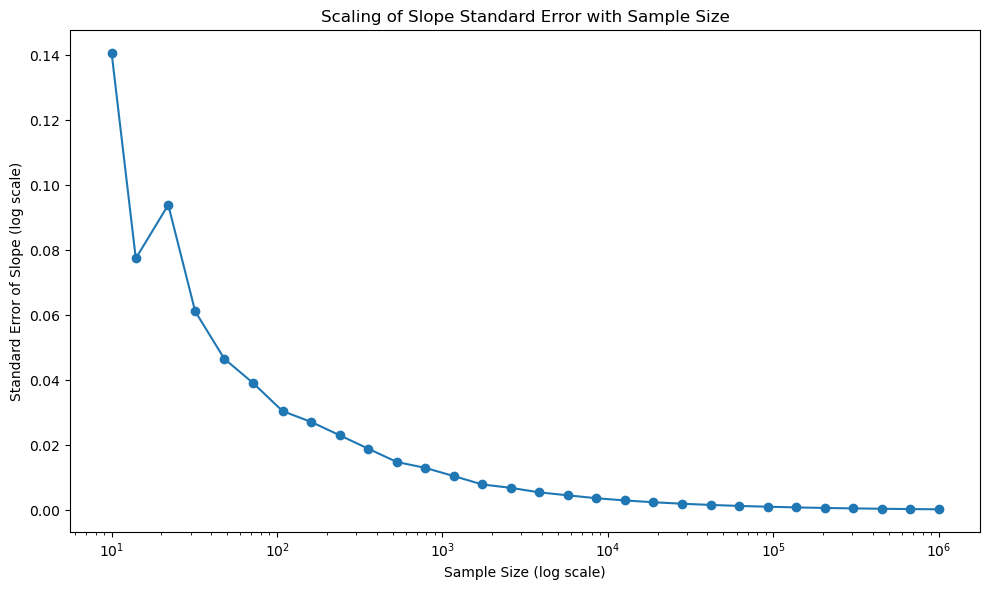

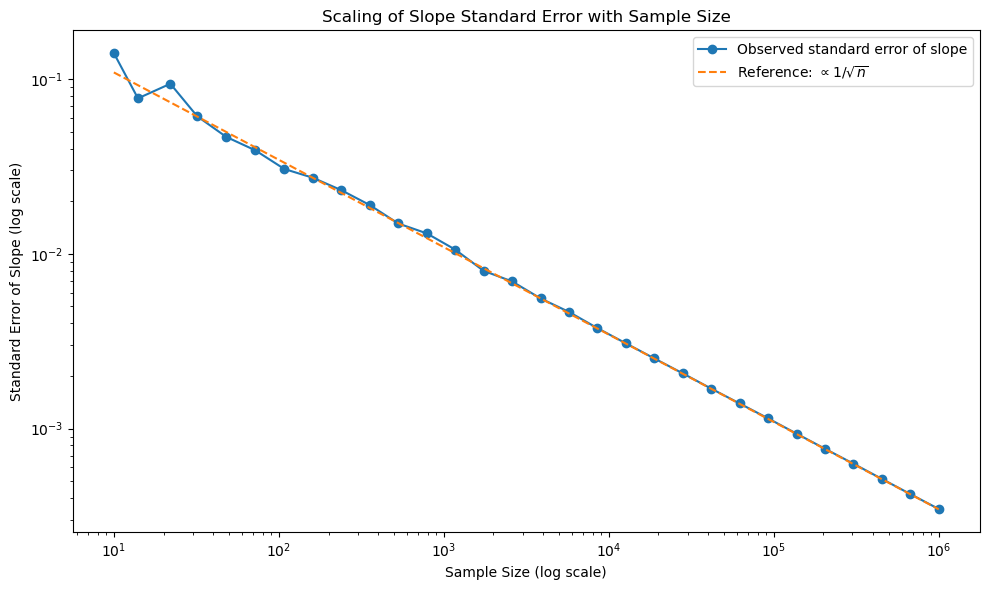

In [20]:
# Building intuition for a simple but important idea:
# All other things being equal, the more rows of data the better for ML.
#
# Here we illustrate that idea for simple linear regression.
#
# Important:
# This demonstration only cleanly shows "more rows is better" because
# the other things are being held fixed:
# - the same true data-generating process
# - the same noise level
# - the same spread of x-values across sample sizes

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# -------------------------------------------------------------------
# True data-generating process
# -------------------------------------------------------------------
true_intercept = 5.0
true_slope = 2.0
noise_std = 10.0

print("Important interpretation note:")
print("This demonstration only cleanly shows 'more rows is better' because")
print("the other things are being held fixed: the same true relationship,")
print("the same noise level, and the same spread of x-values across sample sizes.")
print()

# -------------------------------------------------------------------
# Helper function: generate data and fit simple linear regression
# -------------------------------------------------------------------
def generate_and_fit(n, x_low=0, x_high=100):
    x = np.random.uniform(x_low, x_high, size=n)
    noise = np.random.normal(loc=0, scale=noise_std, size=n)
    y = true_intercept + true_slope * x + noise

    X = x.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)

    intercept_hat = model.intercept_
    slope_hat = model.coef_[0]

    # Residual standard error
    y_hat = model.predict(X)
    residuals = y - y_hat
    residual_variance = np.sum(residuals**2) / (n - 2)
    residual_std = np.sqrt(residual_variance)

    # Standard error of slope:
    # SE(beta_1_hat) = sqrt( sigma^2 / sum((x_i - x_bar)^2) )
    sxx = np.sum((x - x.mean())**2)
    slope_se = np.sqrt(residual_variance / sxx)

    return x, y, intercept_hat, slope_hat, residual_std, slope_se

# -------------------------------------------------------------------
# Small example
# -------------------------------------------------------------------
n_small = 10
x_small, y_small, intercept_small, slope_small, residual_std_small, slope_se_small = generate_and_fit(n_small)

print(f"n = {n_small}")
print("First 10 x values:", [f"{v:.1f}" for v in x_small[:10]])
print("First 10 y values:", [f"{v:.1f}" for v in y_small[:10]])
print("Estimated intercept:", f"{intercept_small:.3f}")
print("Estimated slope:", f"{slope_small:.3f}")
print("Standard error of slope:", f"{slope_se_small:.5f}")
print()

# -------------------------------------------------------------------
# Larger example
# -------------------------------------------------------------------
n_large = 1000
x_large, y_large, intercept_large, slope_large, residual_std_large, slope_se_large = generate_and_fit(n_large)

print(f"n = {n_large}")
print("First 10 x values:", [f"{v:.1f}" for v in x_large[:10]])
print("First 10 y values:", [f"{v:.1f}" for v in y_large[:10]])
print("Estimated intercept:", f"{intercept_large:.3f}")
print("Estimated slope:", f"{slope_large:.3f}")
print("Standard error of slope:", f"{slope_se_large:.5f}")
print()

# -------------------------------------------------------------------
# Generate a range of sample sizes and record regression estimates
# -------------------------------------------------------------------
sizes = np.unique(np.logspace(1, 6, num=30, dtype=int))

estimated_intercepts = []
estimated_slopes = []
slope_standard_errors = []

for n in sizes:
    _, _, intercept_hat, slope_hat, _, slope_se = generate_and_fit(n)

    estimated_intercepts.append(intercept_hat)
    estimated_slopes.append(slope_hat)
    slope_standard_errors.append(slope_se)

estimated_intercepts = np.array(estimated_intercepts)
estimated_slopes = np.array(estimated_slopes)
slope_standard_errors = np.array(slope_standard_errors)

print("Recorded results:")
for n, intercept_hat, slope_hat, slope_se in zip(
    sizes, estimated_intercepts, estimated_slopes, slope_standard_errors
):
    print(
        f"n={n:>8,} | intercept={intercept_hat:8.3f} | "
        f"slope={slope_hat:8.5f} | SE(slope)={slope_se:10.6f}"
    )

# -------------------------------------------------------------------
# Plot 1: Estimated slope ± 1 SEM versus sample size
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.errorbar(
    sizes,
    estimated_slopes,
    yerr=slope_standard_errors,   # 1 standard error
    fmt='o-',
    capsize=4,
    label='Estimated slope ± 1 SEM'
)

plt.axhline(true_slope, color='red', linestyle='--', label='True slope')

plt.xscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Estimated Slope ± 1 SEM')
plt.title('Estimated Regression Slope ± 1 SEM vs Sample Size')
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Plot 2: Standard error of slope versus sample size
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    slope_standard_errors,
    marker='o'
)

plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Standard Error of Slope (log scale)')
plt.title('Scaling of Slope Standard Error with Sample Size')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Plot 3: Standard error of slope versus sample size with reference line
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    slope_standard_errors,
    marker='o',
    label='Observed standard error of slope'
)

# Reference line proportional to 1/sqrt(n), anchored to the middle point
mid_idx = len(sizes) // 2
reference_line = slope_standard_errors[mid_idx] * np.sqrt(sizes[mid_idx] / sizes)

plt.plot(
    sizes,
    reference_line,
    linestyle='--',
    label=r'Reference: $\propto 1/\sqrt{n}$'
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Standard Error of Slope (log scale)')
plt.title('Scaling of Slope Standard Error with Sample Size')
plt.legend()

plt.tight_layout()
plt.show()


# A useful pedagogical note: in regression, the standard error of the slope depends not just on (n), but also on the residual noise and on the spread of the (x)-values. That is why holding the (x)-range fixed matters here.


- The accuracy of a regression estimate is governed by a trade-off between noise level and sample size.
- With a small dataset, you can only recover the true slope if the observations have low noise (high signal-to-noise ratio).
- As the noise increases, you require more data to average out that randomness and recover the underlying relationship.





$${SE}(\hat{\beta}_1) \propto \frac{\sigma}{\sqrt{n}}$$

Increasing noise ($\sigma$) must be compensated by increasing sample size ($n$) to achieve the same estimation precision.

**Low noise can substitute for small data; large data can compensate for high noise.**